## Check if the packages are installed and all function parameters

In [1]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

def save_cleaned_csv(dataframe,filename):
    os.makedirs("Cleaned_Data", exist_ok=True)  # Ensures directory exists
    dataframe.to_csv(f"Cleaned_Data/{filename}.csv")

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("seaborn")
check_installation_and_install("scikit-learn")

pandas is installed
matplotlib is installed
numpy is installed
seaborn is installed


## Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

## Insert Dataset to clean and preprocess

In [2]:
file_directory = "../dataset"

office_1_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part1.csv"))
office_2_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part2.csv"))
small_apartment_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part3.csv"))
small_workshop_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part4.csv"))
kitchen_livingroom_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part5.csv"))
bed_room_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part6.csv"))
boiler_room_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part7.csv"))

df_array = [office_1_df,office_2_df,small_apartment_df,small_workshop_df,kitchen_livingroom_df,bed_room_df,boiler_room_df]

dataset_names = [
    "Office 1", "Office 2", "Small Apartment", "Small Workshop",
    "Kitchen Living Room", "Bedroom", "Boiler Room"
]

for df, name in zip(df_array, dataset_names):
    df['location'] = name

df = pd.concat(df_array)

## Check the data description 

In [3]:
df.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,CH,FRAME_LEN,PREAM_LEN,BITRATE,PRFR,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,CIR9,CIR10,CIR11,CIR12,CIR13,CIR14,CIR15,CIR16,CIR17,CIR18,CIR19,CIR20,CIR21,CIR22,CIR23,CIR24,...,CIR976,CIR977,CIR978,CIR979,CIR980,CIR981,CIR982,CIR983,CIR984,CIR985,CIR986,CIR987,CIR988,CIR989,CIR990,CIR991,CIR992,CIR993,CIR994,CIR995,CIR996,CIR997,CIR998,CIR999,CIR1000,CIR1001,CIR1002,CIR1003,CIR1004,CIR1005,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.0,42000.000000,42000.000000,42000.0,42000.0,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,2.0,33.801762,1042.980571,110.0,64.0,250.406381,224.825762,239.521762,241.794714,254.920238,244.125976,255.616381,266.981690,253.198548,227.669810,243.032000,244.086048,254.270786,243.201190,252.714310,264.986000,250.470738,228.971024,244.525643,247.700262,258.545762,248.861357,256.327310,264.743000,244.465857,...,257.344262,231.431024,240.894214,243.534595,261.747071,252.828833,261.179619,272.133286,254.543905,229.551214,239.281905,240.847524,258.457976,248.063095,255.479690,267.333190,251.259381,225.917690,238.194071,240.025143,259.088000,249.313738,260.392833,273.013095,255.94231,230.181952,240.876929,243.106667,259.899976,246.830500,257.455357,267.230833,249.123929,225.917143,239.445476,240.034286,254.388095,243.190643,253.173595,90.203429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,0.0,5.946221,96.736825,0.0,0.0,132.276784,111.875845,132.534990,133.766124,174.439854,135.793053,144.903120,155.431894,133.345788,114.041728,133.112612,135.638314,172.514693,132.357317,140.996959,151.583544,132.872126,114.966626,134.316867,137.958100,175.654374,137.359377,142.771904,152.905251,128.009545,...,137.845725,115.793941,130.692309,133.059149,180.042079,141.507442,150.304418,158.002282,135.554861,115.087583,129.686129,132.740620,179.261639,139.792929,147.807842,156.765691,134.182081,113.215954,128.765754,133.056841,179.449331,139.158334,149.661940,156.860668,135.29612,115.559235,131.270815,134.342692,179.987936,137.462906,148.613220,155.703171,132.054825,113.041790,131.519415,133.820366,177.274537,135.598470,145.780909,145.839730
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,2.0,27.000000,1024.000000,110.0,64.0,2.000000,3.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,

## Removal of Unnecessary Columns

In [4]:
df = df.drop(columns=['CH','PREAM_LEN','BITRATE','PRFR'], axis=1)
df.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,FRAME_LEN,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,CIR9,CIR10,CIR11,CIR12,CIR13,CIR14,CIR15,CIR16,CIR17,CIR18,CIR19,CIR20,CIR21,CIR22,CIR23,CIR24,CIR25,CIR26,CIR27,CIR28,...,CIR976,CIR977,CIR978,CIR979,CIR980,CIR981,CIR982,CIR983,CIR984,CIR985,CIR986,CIR987,CIR988,CIR989,CIR990,CIR991,CIR992,CIR993,CIR994,CIR995,CIR996,CIR997,CIR998,CIR999,CIR1000,CIR1001,CIR1002,CIR1003,CIR1004,CIR1005,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,33.801762,250.406381,224.825762,239.521762,241.794714,254.920238,244.125976,255.616381,266.981690,253.198548,227.669810,243.032000,244.086048,254.270786,243.201190,252.714310,264.986000,250.470738,228.971024,244.525643,247.700262,258.545762,248.861357,256.327310,264.743000,244.465857,223.576048,238.577500,241.825357,254.621071,...,257.344262,231.431024,240.894214,243.534595,261.747071,252.828833,261.179619,272.133286,254.543905,229.551214,239.281905,240.847524,258.457976,248.063095,255.479690,267.333190,251.259381,225.917690,238.194071,240.025143,259.088000,249.313738,260.392833,273.013095,255.94231,230.181952,240.876929,243.106667,259.899976,246.830500,257.455357,267.230833,249.123929,225.917143,239.445476,240.034286,254.388095,243.190643,253.173595,90.203429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,5.946221,132.276784,111.875845,132.534990,133.766124,174.439854,135.793053,144.903120,155.431894,133.345788,114.041728,133.112612,135.638314,172.514693,132.357317,140.996959,151.583544,132.872126,114.966626,134.316867,137.958100,175.654374,137.359377,142.771904,152.905251,128.009545,109.901241,128.805257,133.764226,171.596265,...,137.845725,115.793941,130.692309,133.059149,180.042079,141.507442,150.304418,158.002282,135.554861,115.087583,129.686129,132.740620,179.261639,139.792929,147.807842,156.765691,134.182081,113.215954,128.765754,133.056841,179.449331,139.158334,149.661940,156.860668,135.29612,115.559235,131.270815,134.342692,179.987936,137.462906,148.613220,155.703171,132.054825,113.041790,131.519415,133.820366,177.274537,135.598470,145.780909,145.839730
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,27.000000,2.000000,3.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.

## Check Any Missing Value

In [5]:
print(f"DataFrame Missing Values:")
print(df.isnull().sum().unique())

DataFrame Missing Values:
[0]


## Check for any duplicated values

In [6]:
duplicate = df[df.duplicated()]

if not duplicate.empty:
    print("Duplicate Rows :")
    print(duplicate)
    print("-" * 30)
else:
    print("No duplicate rows found")
    print("-" * 30)

No duplicate rows found
------------------------------


## Check valid data types 

In [7]:
def check_data_types(df):
    print(f"Dataset: {df.dtypes.unique()}")

print("Data Types : {check_data_types(df)}")

float_cols = df.select_dtypes(include=['float64']).columns
object_cols = df.select_dtypes(include=['O']).columns

print("Float64 columns:", float_cols)
print("Object columns:", object_cols)

Data Types : {check_data_types(df)}
Float64 columns: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1027)
Object columns: Index(['location'], dtype='object')


## Feature Importance
After exploring with an list of numbers: 50,100,200.
Best Result is 50

In [8]:
# Dictionary to store top feature names per dataset
feature_list_names = {}

def explore_feature_random_forest(df,n_features):    
    global feature_list_names  # Ensure we update the global dictionary

    # Separate features and target variable
    X = df.drop(columns=['location','RANGE'], errors='ignore')
    y = df['RANGE']

    # Train Random Forest for exploration
    clf = RandomForestRegressor(n_estimators=100, random_state=42)
    clf.fit(X, y)

    # Get feature importance
    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
    feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

    # Store top 'n_features' in dictionary with dataset index as key
    feature_list_names= feature_importance.head(n_features)['Feature'].tolist()

    # Print results
    print(f"Top {n_features} Important Features:")
    print(feature_importance.head(n_features))

# Example call
explore_feature_random_forest(df, 50)

KeyboardInterrupt: 

## Repopulate the df_array with the features required

In [ ]:
def repopulate_array(df, feature_dict):
    selected_features = set()
    for feature in feature_dict:
        selected_features.add(feature)
    selected_features.add('RANGE')
    selected_features = df.columns.intersection(selected_features)  # Avoid KeyError
    df_filtered = df[selected_features]

    return df_filtered

df_feature_importance = repopulate_array(df,feature_list_names)

df_feature_importance.describe()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR745,CIR746,CIR747,CIR748,CIR749,CIR750,CIR751,CIR752,CIR753,CIR754
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,...,3852.530119,5087.995071,6165.303024,7160.961667,8033.931238,8734.224714,8913.399333,8438.733048,7676.693786,6977.234333
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,...,5080.697561,5663.507315,5798.118763,5709.252332,5463.281026,5259.482597,5344.375031,5351.439325,5089.513498,4794.354904
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,...,2.000000,2.000000,2.000000,4.000000,7.000000,15.000000,38.000000,8.000000,7.000000,6.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,56.000000,6727.000000,961.000000,318.00000,...,243.000000,346.000000,991.000000,2297.000000,3536.000000,4414.000000,4435.750000,3988.000000,3543.000000,3169.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,68.000000,9950.500000,1134.000000,513.00000,...,1288.000000,2854.000000,4424.000000,5825.500000,6900.000000,7766.500000,8023.000000,7339.000000,6527.000000,5842.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,80.000000,12443.000000,1488.000000,1024.00000,...,5687.500000,8141.250000,9942.250000,11223.250000,12066.000000,12654.500000,13064.000000,12362.000000,11054.250000,9886.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,324.000000,37208.000000,5169.000000,1056.00000,...,23397.000000,23411.000000,23450.000000,23463.000000,23459.000000,23405.000000,23501.000000,23377.000000,23361.000000,23260.000000


## Check for Outliers

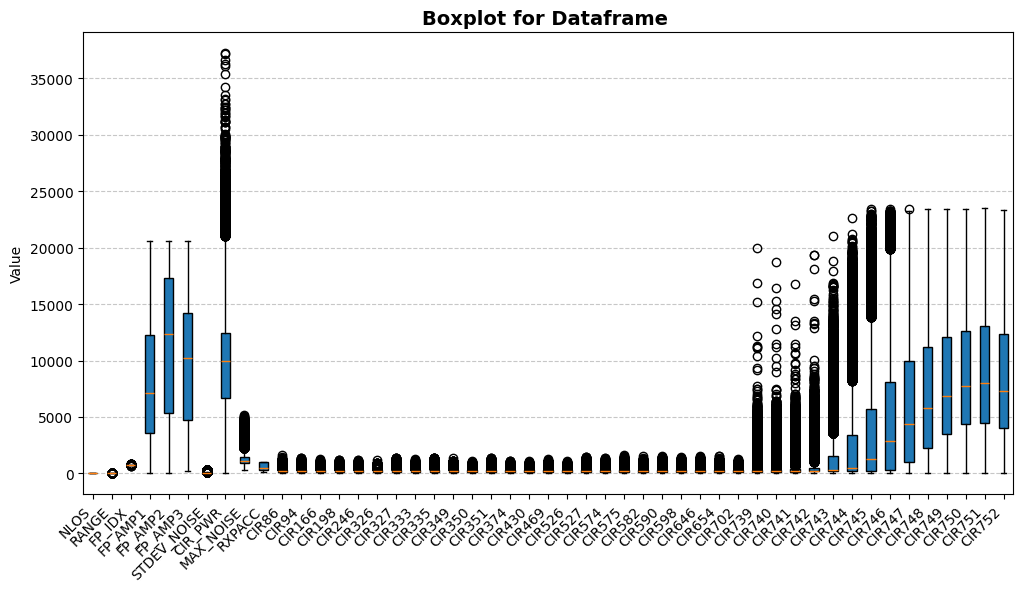

In [ ]:
# columns_to_check = [
#     "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
#     "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC",
#     "FRAME_LEN"
# ]

columns_to_check = df_feature_importance.columns[:-2] #Get all columns except the last column
plt.figure(figsize=(12, 6)) #Create a 12x6 figure for the plot
plt.boxplot(df_feature_importance[columns_to_check], vert=True, patch_artist=True) #Create a boxplot for columns 


plt.xticks(range(1, len(columns_to_check) + 1), columns_to_check, rotation=45, ha="right") #Configuring x label
plt.title(f"Boxplot for Dataframe ", fontsize=14, fontweight="bold") #Add a title
plt.ylabel("Value") #Add y label
plt.grid(axis='y', linestyle='--', alpha=0.7) #Add grid to the plot

plt.show()

## Remove Outliers

In [ ]:
#Outliers are removed using Z Score
def calculate_mean(column):
    return sum(column) / len(column)

def calculate_std(column, mean):
    if len(column) < 2:
        return 0
    variance = sum((x - mean) ** 2 for x in column) / len(column) #Average Squared difference from the mean
    return variance ** 0.5 

def remove_outliers(df,columns, threshold=3):
    for col in columns:
        if col in df.columns:
            column_data = df[col].dropna().tolist() #Converting to list

            mean = calculate_mean(column_data) #Calculate mean for column
            std = calculate_std(column_data, mean) #Calculate STD for column

            #Filter rows where absolute Z score is less than threshold
            #Rows that has zScore greater or equal to threshold are removed as they will be considered outlier
            df_filtered_rows = df[[abs((x - mean)/ std) < threshold if not pd.isna(x) else False for x in df[col]]] 
            
    return df_filtered_rows

df_feature_importance = remove_outliers(df_feature_importance, columns_to_check)

df_feature_importance.shape

(42000, 51)

## Check after outliners removal 

In [ ]:
df_feature_importance.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR745,CIR746,CIR747,CIR748,CIR749,CIR750,CIR751,CIR752,CIR753,CIR754
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,...,3852.530119,5087.995071,6165.303024,7160.961667,8033.931238,8734.224714,8913.399333,8438.733048,7676.693786,6977.234333
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,...,5080.697561,5663.507315,5798.118763,5709.252332,5463.281026,5259.482597,5344.375031,5351.439325,5089.513498,4794.354904
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,...,2.000000,2.000000,2.000000,4.000000,7.000000,15.000000,38.000000,8.000000,7.000000,6.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,56.000000,6727.000000,961.000000,318.00000,...,243.000000,346.000000,991.000000,2297.000000,3536.000000,4414.000000,4435.750000,3988.000000,3543.000000,3169.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,68.000000,9950.500000,1134.000000,513.00000,...,1288.000000,2854.000000,4424.000000,5825.500000,6900.000000,7766.500000,8023.000000,7339.000000,6527.000000,5842.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,80.000000,12443.000000,1488.000000,1024.00000,...,5687.500000,8141.250000,9942.250000,11223.250000,12066.000000,12654.500000,13064.000000,12362.000000,11054.250000,9886.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,324.000000,37208.000000,5169.000000,1056.00000,...,23397.000000,23411.000000,23450.000000,23463.000000,23459.000000,23405.000000,23501.000000,23377.000000,23361.000000,23260.000000


## Checking Covariance (How Two Variables Vary Together Through a linear relationship)

DataFrame


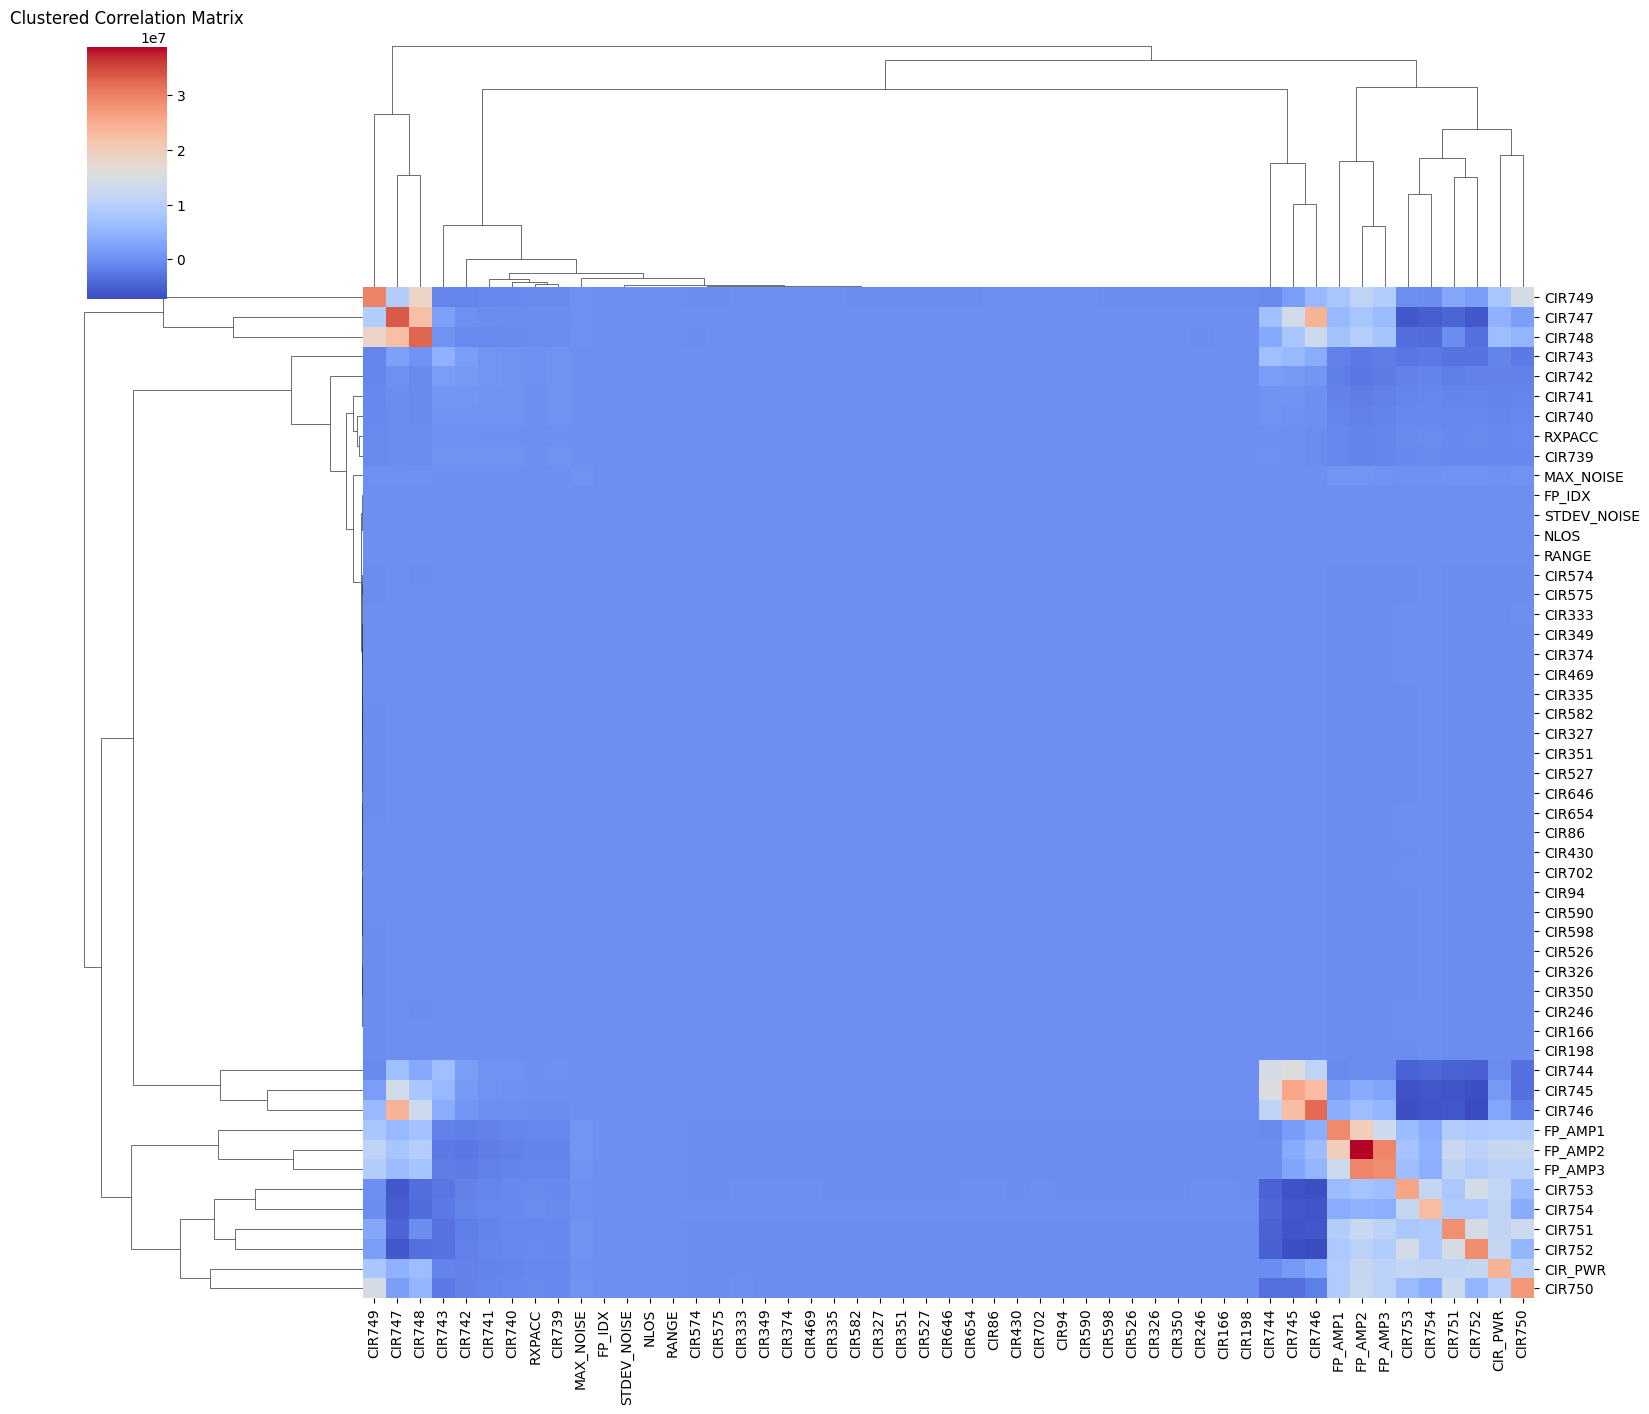

--------------------------------------------------


In [ ]:
cov_matrix = df_feature_importance.cov()

print(f"DataFrame")
sns.clustermap(cov_matrix,  cmap="coolwarm", figsize=(16, 14))
plt.title("Clustered Correlation Matrix")
plt.show()
print("-" * 50)

## Checking Correlation (Strength & Direction of Relationships)

DataFrame


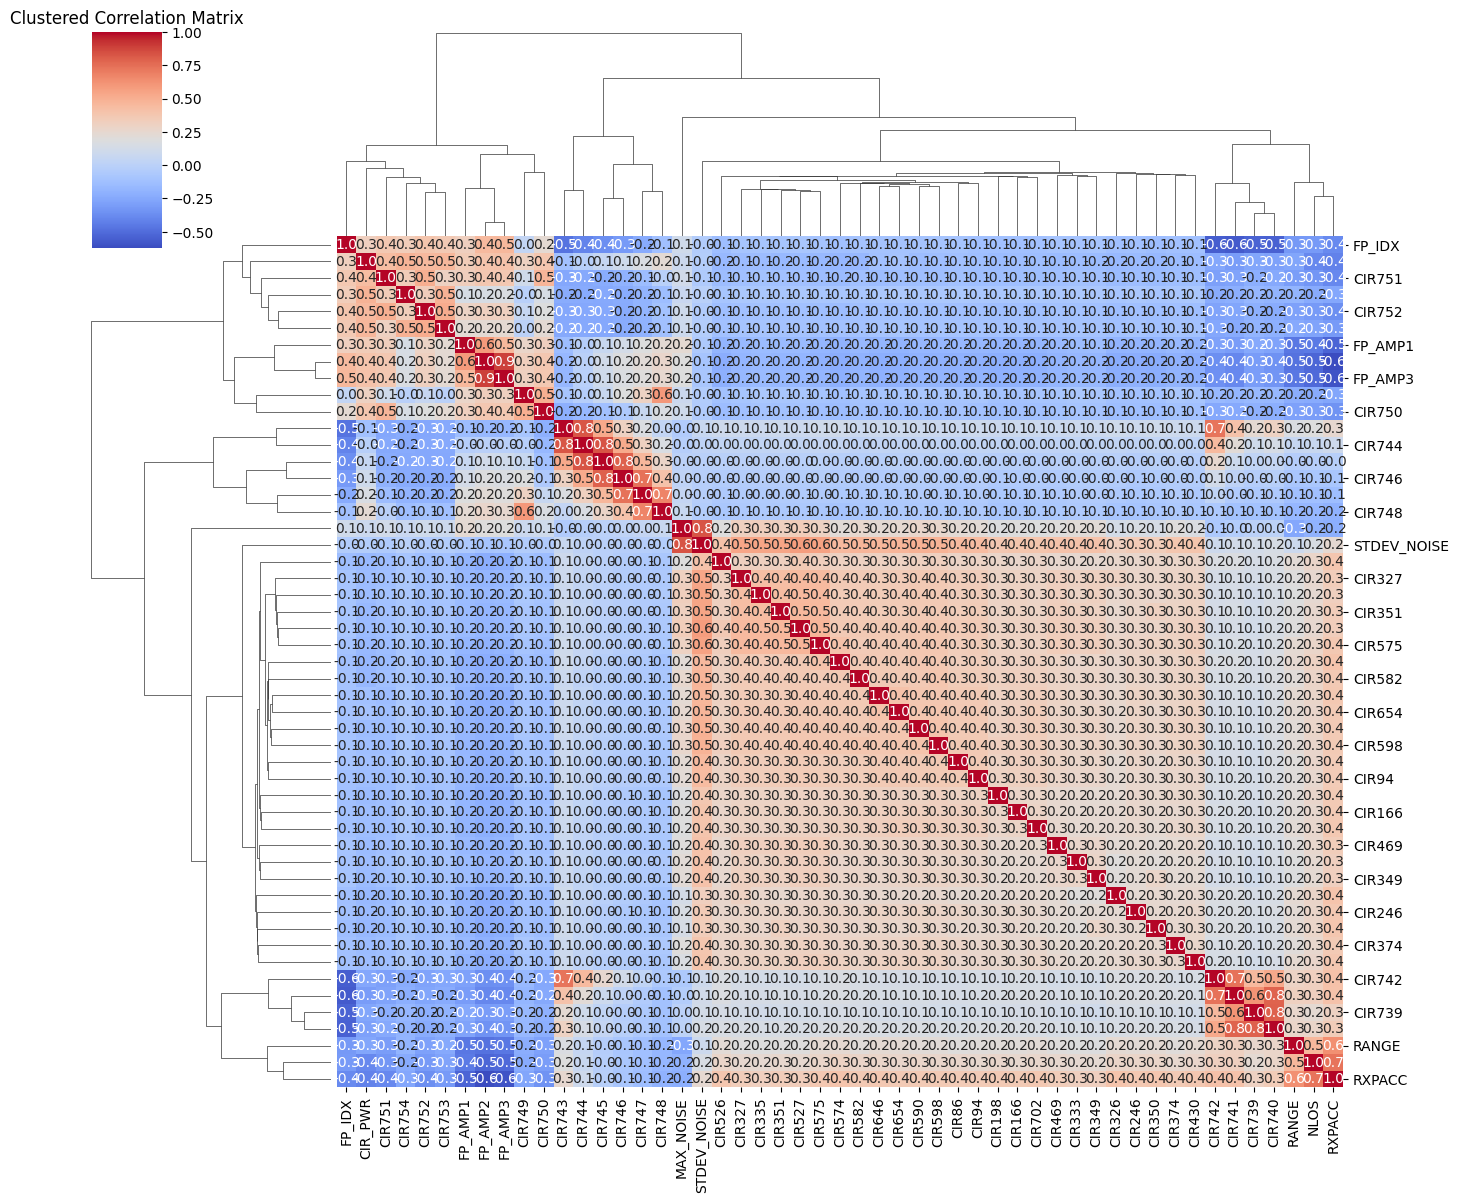

--------------------------------------------------


In [ ]:
corr_matrix = df_feature_importance.corr()
print(f"DataFrame")

sns.clustermap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f", figsize=(14, 12))
plt.title("Clustered Correlation Matrix")
plt.show()
print("-" * 50)

## Do Principal Component Analysis 


Dataset

Transformed DataFrame after PCA:


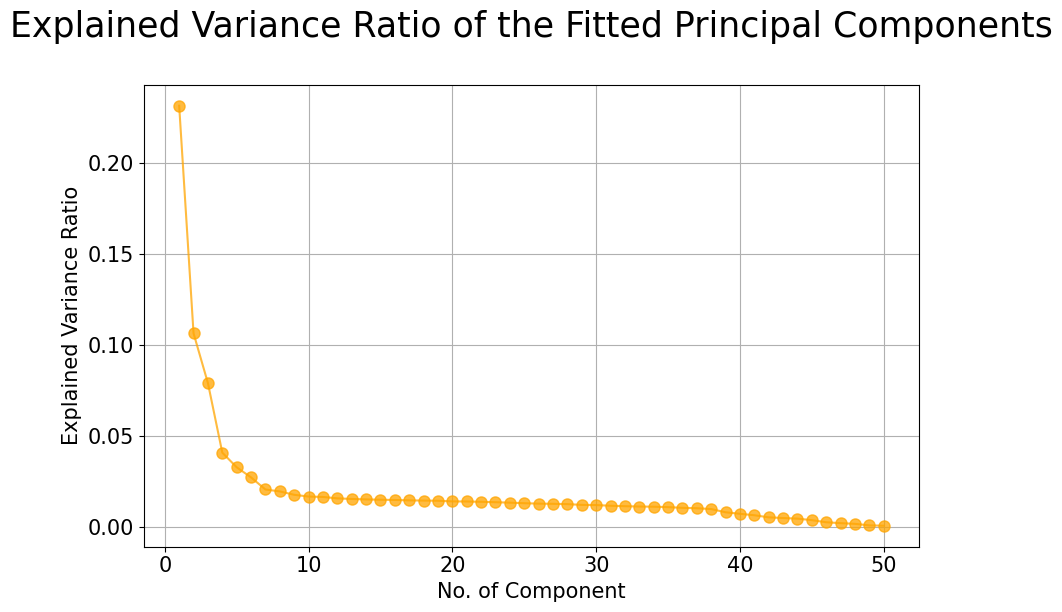

In [ ]:
#Standardize the Data
dfx = {}

print(f"\nDataset")

X = df_feature_importance.drop('RANGE',axis=1)
y = df_feature_importance['RANGE']

#Training and Test data Spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Standardize the Data
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)

#Store standardized data
dfx = pd.DataFrame(data=X_train_scaled ,columns=X.columns)

print("\nTransformed DataFrame after PCA:")

#Apply PCA
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_scaled)

#Plot 
plt.figure(figsize=(10, 6))
plt.plot([i+1 for i in range(len(pca.explained_variance_ratio_))],
         pca.explained_variance_ratio_,
         marker='o', linestyle='-', color='orange', markersize=8, alpha=0.75)
plt.grid(True)
plt.title("Explained Variance Ratio of the Fitted Principal Components\n", fontsize=25)
plt.yticks(fontsize=15)
plt.ylabel("Explained Variance Ratio", fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel("No. of Component", fontsize=15)

plt.show()

#Find minimum number of components that explain 95% of variance
# explained_variance = np.cumsum(pca.explained_variance_ratio_)
# n_components = 

# 0.001 is added to avoid floating point error


### Dropping data that are < 0.015

In [ ]:
df_clean = {}
used_features = set() 
dominant_features = []

print(f"\nProcessing PCA for: Dataset")

pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(dfx)

explained_variance = pca.explained_variance_ratio_

# Filter components with explained variance >= 0.015
# Can be changed to 0.01
selected_components = np.where(explained_variance >= 0.015)[0]

X_train_pca_filtered = X_train_pca[:, selected_components]

feature_contributions = np.abs(pca.components_)  

original_features = dfx.columns 
# print(f"original_features{original_features}")

for i in selected_components:
    contributions = feature_contributions[i].copy() 
    for idx, feature in enumerate(original_features):
        if feature in used_features:
            contributions[idx] = -np.inf  

    max_index = np.argmax(contributions) 
    chosen_feature = original_features[max_index]

    dominant_features.append(chosen_feature)
    used_features.add(chosen_feature)

# print(f"dominant_features: {dominant_features}")


pca_column_labels = [f"{feature}" for feature in dominant_features]

# print(f"pca_column_labels{pca_column_labels}")

df_pca = pd.DataFrame(data=df, columns=pca_column_labels)

df_clean = df_pca

print("\nFiltered PCA DataFrame:")
df_clean.describe()




Processing PCA for: Dataset

Filtered PCA DataFrame:


,RXPACC,FP_IDX,CIR746,CIR740,CIR749,CIR_PWR,CIR750,CIR575,CIR326,CIR333,CIR349,CIR350,CIR246
count,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,616.27250,745.654167,5087.995071,420.923190,8033.931238,9789.690214,8734.224714,250.025310,233.573571,231.440095,230.114738,234.509738,237.211619
std,306.78537,4.505024,5663.507315,697.420038,5463.281026,4912.556005,5259.482597,155.077317,119.714189,122.089565,121.221054,120.759067,122.969410
min,128.00000,707.000000,2.000000,1.000000,7.000000,0.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,318.00000,744.000000,346.000000,163.000000,3536.000000,6727.000000,4414.000000,147.000000,151.000000,150.000000,149.000000,150.000000,153.000000
50%,513.00000,746.000000,2854.000000,240.000000,6900.000000,9950.500000,7766.500000,231.000000,221.000000,219.000000,219.000000,222.000000,223.000000
75%,1024.00000,748.000000,8141.250000,332.000000,12066.000000,12443.000000,12654.500000,310.000000,287.000000,282.000000,281.000000,289.000000,290.000000
max,1056.00000,848.000000,23411.000000,18755.000000,23459.000000,37208.000000,23405.000000,1598.000000,1187.000000,1305.000000,1337.000000,1071.000000,1198.000000


### Testing accuracy


In [ ]:
df_accuracy = {}

print(f"\nEvaluating Accuracy for:Dataset")

original_df = df

X = original_df.drop(['RANGE','location'], axis=1)
y = original_df['RANGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=df_pca.shape[1])  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model = LogisticRegression()
model.fit(X_train_pca, y_train)

y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

df_accuracy = pd.DataFrame({
    "Metric": ["Train Accuracy", "Test Accuracy"],
    "Accuracy": [train_accuracy, test_accuracy]
})

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nFinal Accuracy Table:")
print(df_accuracy)


Evaluating Accuracy for:Dataset
Train Accuracy: 0.8442
Test Accuracy: 0.8426

Final Accuracy Table:
           Metric  Accuracy
0  Train Accuracy  0.844159
1   Test Accuracy  0.842571


In [ ]:

df_clean = df_clean.drop(columns=[col for col in ['index', 'level_0', 'location'] if col in df_clean.columns])

print(df_clean.head())


df_clean = df_clean.reset_index(drop=True) 
df_clean = df_clean.loc[~df_clean.index.duplicated()]  


for col in ['NLOS', 'RANGE']:
    if col not in df_clean.columns and col in df.columns:
        df_clean[col] = df[col].values  

print("\nFinal Cleaned DataFrame:")
print(df_clean.head())


save_cleaned_csv(df_clean, "Range_Cleaned_Data")


   RXPACC  FP_IDX   CIR746  CIR740   CIR749  CIR_PWR   CIR750  CIR575  CIR326  \
0   611.0   745.0   6102.0   266.0   9621.0  11855.0   8303.0   106.0   150.0   
1   447.0   749.0    194.0    10.0   1840.0  18968.0   5244.0   245.0   263.0   
2   723.0   746.0   1212.0   500.0   4489.0  14699.0   2992.0    73.0   172.0   
3  1024.0   750.0    292.0   241.0   1424.0   8748.0   2907.0   418.0   213.0   
4   276.0   746.0  11949.0   280.0  16162.0  11380.0  19583.0   185.0    68.0   

   CIR333  CIR349  CIR350  CIR246  NLOS  RANGE  
0   182.0   179.0   215.0   284.0   0.0   3.90  
1   247.0   123.0   299.0   230.0   0.0   0.66  
2   265.0   205.0   180.0   314.0   1.0   7.86  
3   250.0   157.0   345.0   317.0   1.0   3.48  
4   240.0    42.0   338.0   152.0   0.0   1.19  

Final Cleaned DataFrame:
   RXPACC  FP_IDX   CIR746  CIR740   CIR749  CIR_PWR   CIR750  CIR575  CIR326  \
0   611.0   745.0   6102.0   266.0   9621.0  11855.0   8303.0   106.0   150.0   
1   447.0   749.0    194.0    1